In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.ticker import NullFormatter
from scipy.stats import norm, multivariate_normal, pearsonr
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2
from scipy import interpolate
import seaborn as sb
import matplotlib
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.optimize import curve_fit
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

In [2]:
data = np.load('sunspot.npz')
B = data['B']
theta = np.degrees(data['inc'])
phi = np.degrees(data['az'])

datasets = [
    (B, 'Jacina magnetnog polja (B)', 'Gauss', 'viridis'),
    (theta, 'Inklinacija (theta)', 'Stepeni', 'plasma'),
    (phi, 'Azimut (phi)', 'Stepeni', 'twilight')
]

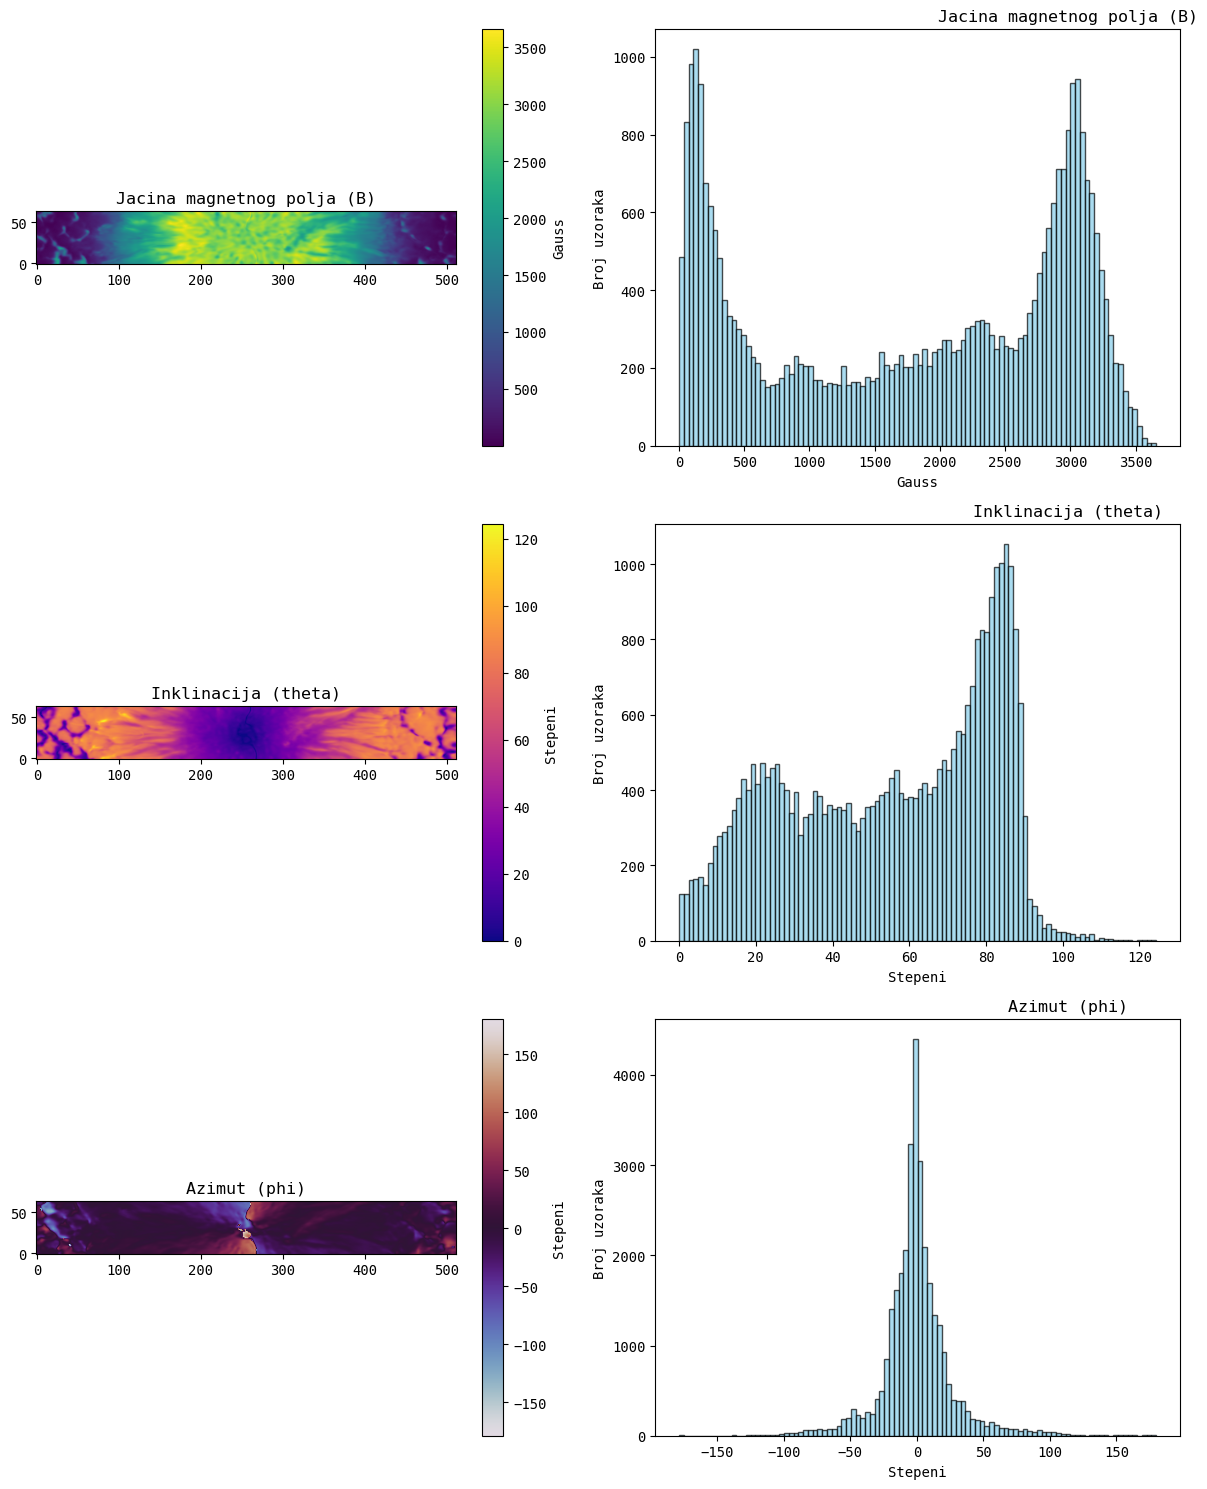

In [3]:
# PRVI ZADATAK - MAPE I HISTOGRAMI

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, (data, title, unit, cmap) in enumerate(datasets):
    # Mape
    im = axes[i, 0].imshow(data, cmap=cmap, origin='lower')
    axes[i, 0].set_title(f'{title}')
    fig.colorbar(im, ax=axes[i, 0], label=unit)
    
    # Histogrami
    # .flatten jer je hist() namenjen 1D nizovima
    axes[i, 1].hist(data.flatten(), bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'                              {title}')
    axes[i, 1].set_xlabel(unit)
    axes[i, 1].set_ylabel('Broj uzoraka')

plt.tight_layout()
plt.show()

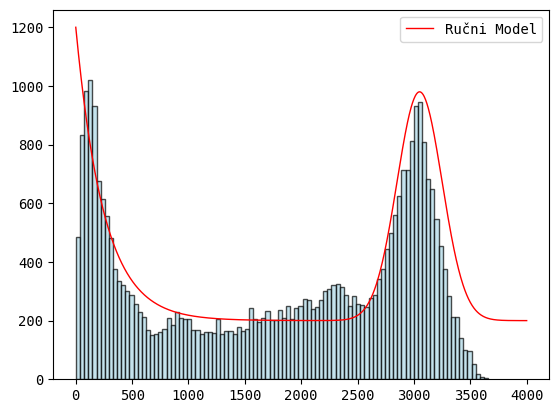

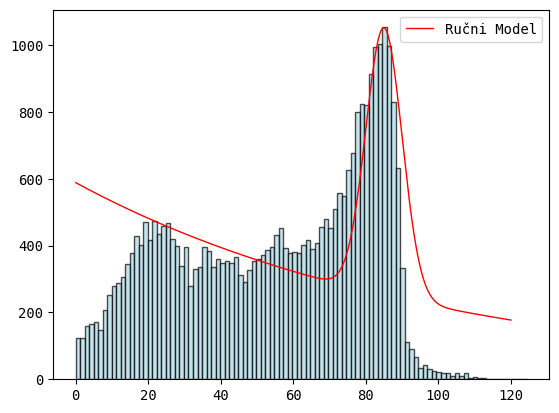

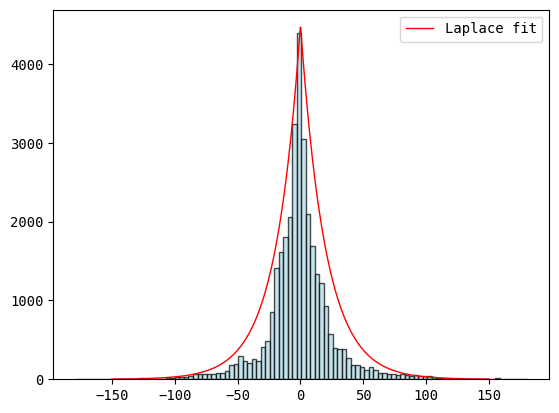

In [4]:
# DRUGI ZADATAK

# B ###################################

x = np.linspace(0, 4000, 1000)

# Eksponencijalna (levi deo)
amp_exp = 1000
decay = 0.004
y_exp = amp_exp * np.exp(-decay * x)

# Gausova (desni deo)
amp_gauss = 780
mu = 3050
sigma = 200
y_gauss = amp_gauss * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Uniformna (ravan pod)
y_uni = np.full_like(x, 200)

# Ukupni model
y_total = y_exp + y_gauss + y_uni
# ------------------------------------

plt.hist(B.flatten(), bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.plot(x, y_total, color='red', lw=1, label='Ručni Model')
plt.legend()
plt.show()


# theta ################################

x = np.linspace(0, 120, 1000)

# Eksponencijalna (levi deo)
amp_exp = 600
decay = 0.01
y_exp = amp_exp * np.exp(-decay * (x+2))

# Gausova (desni deo)
amp_gauss = 800           # amplituda
mu = 85                                  
sigma = 5                # sirina
y_gauss = amp_gauss * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Ukupni model
y_total = y_exp + y_gauss 
# ------------------------------------

plt.hist(theta.flatten(), bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.plot(x, y_total, color='red', lw=1, label='Ručni Model')
plt.legend()
plt.show()


# azimut ######################################

x = np.linspace(-150, 150, 1000)

l = laplace(0, 20) 
amplituda = 180000  # (4500 * 4 jer scale=20)

plt.hist(phi.flatten(), bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.plot(x, amplituda * l.pdf(x), color='red', lw=1, label='Laplace fit')
plt.legend()
plt.show()



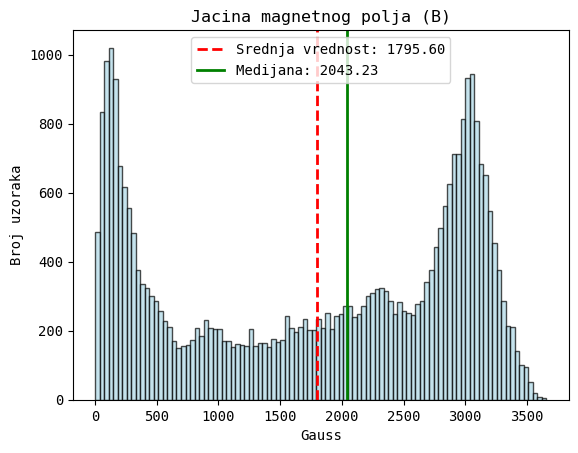

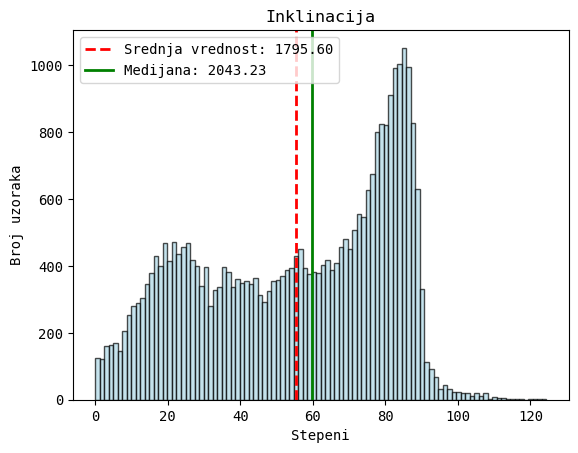

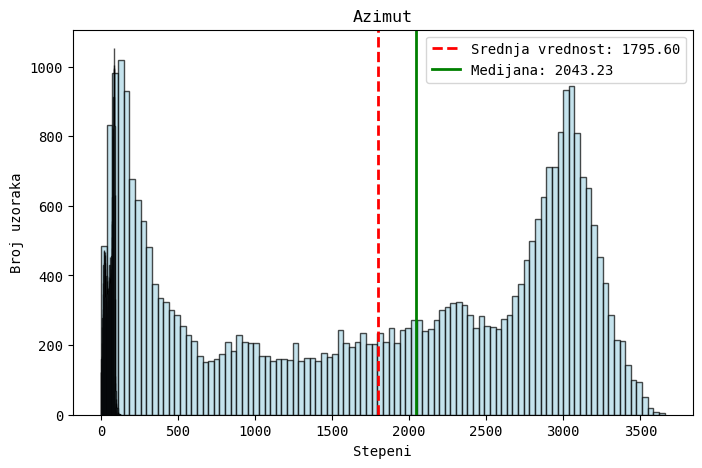

In [5]:
# TRECI ZADATAK

# Magnetno polje B
B_flat = B.flatten()
x_B = np.mean(B_flat)
s_B = np.std(B_flat)
med_B = np.median(B_flat)
q25_B, q75_B = np.percentile(B_flat, [25, 75])
sigG_B = (q75_B - q25_B) / 1.349

plt.hist(B_flat, bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(x_B, color='red', linestyle='dashed', linewidth=2, label=f'Srednja vrednost: {x_B:.2f}')
plt.axvline(med_B, color='green', linestyle='-', linewidth=2, label=f'Medijana: {med_B:.2f}')

plt.title('Jacina magnetnog polja (B)')
plt.xlabel('Gauss')
plt.ylabel('Broj uzoraka')
plt.legend()
plt.show()




# Inklinacija theta
th_flat = theta.flatten()
x_th = np.mean(th_flat)
s_th = np.std(th_flat)
med_th = np.median(th_flat)
q25_th, q75_th = np.percentile(th_flat, [25, 75])
sigG_th = (q75_th - q25_th) / 1.349

plt.hist(th_flat, bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(x_th, color='red', linestyle='dashed', linewidth=2, label=f'Srednja vrednost: {x_B:.2f}')
plt.axvline(med_th, color='green', linestyle='-', linewidth=2, label=f'Medijana: {med_B:.2f}')

plt.title('Inklinacija')
plt.xlabel('Stepeni')
plt.ylabel('Broj uzoraka')
plt.legend()
plt.show()


# Azimut phi
ph_flat = phi.flatten()
x_ph = np.mean(ph_flat)
s_ph = np.std(ph_flat)
med_ph = np.median(ph_flat)
q25_ph, q75_ph = np.percentile(ph_flat, [25, 75])
sigG_ph = (q75_ph - q25_ph) / 1.349

plt.figure(figsize=(8, 5))
plt.hist(B_flat, bins=100, color='lightblue', edgecolor='black', alpha=0.7)

plt.hist(th_flat, bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(x_B, color='red', linestyle='dashed', linewidth=2, label=f'Srednja vrednost: {x_B:.2f}')
plt.axvline(med_B, color='green', linestyle='-', linewidth=2, label=f'Medijana: {med_B:.2f}')

plt.title('Azimut')
plt.xlabel('Stepeni')
plt.ylabel('Broj uzoraka')
plt.legend()
plt.show()